(392,)
[('mpg', '<f8'), ('cylinders', '<i4'), ('displacement', '<f8'), ('horsepower', '<i4'), ('weight', '<i4'), ('acceleration', '<f8'), ('model_year', '<i4'), ('origin', '<i4'), ('car_name', '<U36')]
[(26. , 4, 97., 46, 1835, 20.5, 70, 2, 'volkswagen 1131 deluxe sedan')
 (26. , 4, 97., 46, 1950, 21. , 73, 2, 'volkswagen super beetle')
 (43.1, 4, 90., 48, 1985, 21.5, 78, 2, 'volkswagen rabbit custom diesel')
 (44.3, 4, 90., 48, 2085, 21.7, 80, 2, 'vw rabbit c (diesel)')
 (43.4, 4, 90., 48, 2335, 23.7, 80, 2, 'vw dasher (diesel)')
 (29. , 4, 68., 49, 1867, 19.5, 73, 2, 'fiat 128')
 (31. , 4, 76., 52, 1649, 16.5, 74, 3, 'toyota corona')
 (29. , 4, 85., 52, 2035, 22.2, 76, 1, 'chevrolet chevette')
 (32.8, 4, 78., 52, 1985, 19.4, 78, 3, 'mazda glc deluxe')
 (44. , 4, 97., 52, 2130, 24.6, 82, 2, 'vw pickup')]


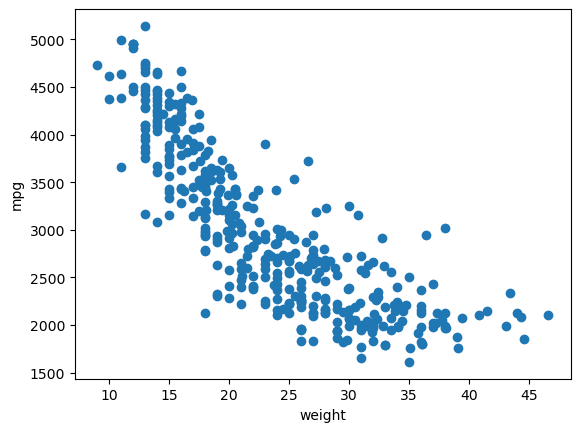

a - -0.9655469842102783 
b - 0.7578596740980378


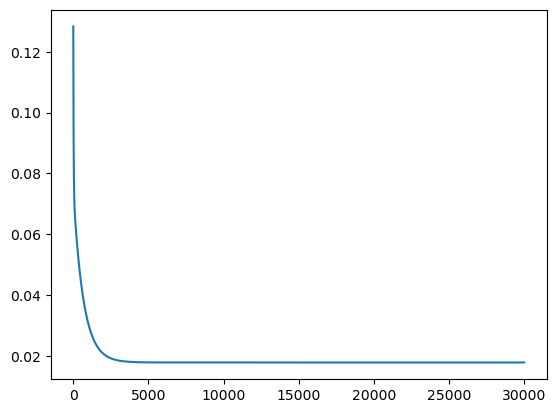

a - -0.9648848135579718 
b - 0.7575954205390757


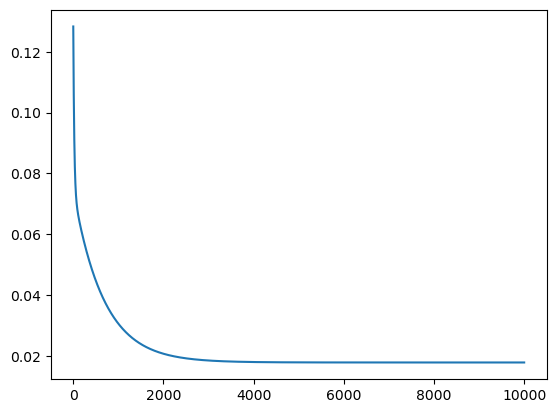

0.6926301056864552
0.6918419777523179


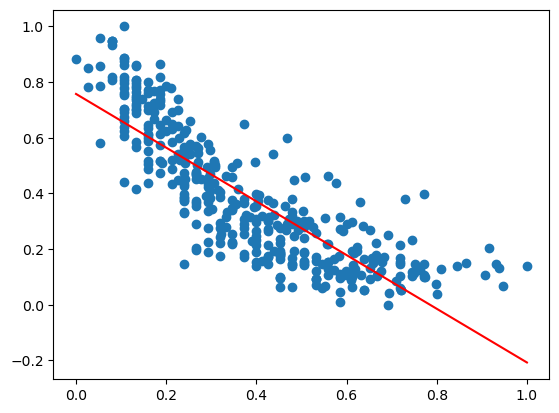

In [67]:
import matplotlib.pyplot as plt
import numpy as np

##1. Read and load data from auto-mpg.data.csv


file = "dataset/auto-mpg-clean.csv"

data = np.genfromtxt(file, dtype=None, names=True, delimiter=",", encoding = None)

print(data.shape)
print(data.dtype)
print(data[:10])

X = data[data.dtype.names[0]]

Y = data[data.dtype.names[4]]

##2. Plot scatter diagram with MPG and Weight

plt.scatter(X, Y)

plt.ylabel("mpg")
plt.xlabel("weight")
plt.show()

##3. Standardise the data using max, min formula

normX, normY = 0 , 0

##scale X and Y
normX = (X - X.min()) / X.ptp()  # Min-max normalization for X
normY = (Y - Y.min()) / Y.ptp()  # Min-max normalization for Y

# Building the model.
# calculate predicted value, cost and change.
# X and Y are original data and label.

def forward(a, b, X, Y):
       
    m = X.shape[0] # Number of elements in X
    Y_pred, cost, D_a, D_b = 0,0,0,0
    
    ## Uncomment the following lines and fill in with your answer   
    ## The predicted value of Y
    
    Y_pred = a * X + b
    
    ## Calculate the cost
    
    cost = (1/m) * np.sum(np.square((Y_pred - Y)))
    
    ## Calculate Derivative a, b
    D_a = (2 / m) * np.sum((Y_pred - Y) * X)
    D_b = (2 / m) * np.sum(Y_pred - Y)   
    
    return {
        "Y_pred" : Y_pred,
        "cost" : cost,
        "D_a" : D_a,
        "D_b" : D_b
    }

def gradient( X, Y, learning_rate = 0.01, epoch = 30000):
    a = 0.1
    b = 0.1
    
    cost = np.zeros(epoch)
    
    for i in range(epoch): 
        parameters = {}
        
        ## Uncomment the following line and fill in wiht your answer
        
        parameters = forward(a, b, X, Y)
        a = a - learning_rate * parameters["D_a"]  # Update a
        b = b - learning_rate * parameters["D_b"]  # Update b
        cost[i] = parameters["cost"]
        
    return a, b, cost
    
learning_rate = 0.01  # The learning Rate
epoch = 30000  # The number of iterations to perform gradient descent
a, b, cost = gradient(normX, normY, learning_rate, epoch)
print ("a - " + str(a), "\nb - " + str(b))
plt.plot(cost)
plt.show()

epoch = 10000  # The number of iterations to perform gradient descent
a, b, cost = gradient(normX, normY, learning_rate, epoch)
print ("a - " + str(a), "\nb - " + str(b))
plt.plot(cost)
plt.show()

def r_squared(Y, Y_pred, num_feature):
    
    ss_err, ss_tot, r2, adjusted_r2 = 0,0,0,0
    
    ## Calculate sum squares residual errors and sum squares total
    
    ss_err = np.sum(np.square((Y_pred - Y)))

    ss_tot = np.sum(np.square((Y - np.mean(Y))))
    
    ## Calculate R-square and Adjusted R-square
    
    r2 = 1 - (ss_err/ss_tot)

    adjusted_r2 = 1 - ( ((1-r2) * (len(Y)-1)) / (len(Y)-num_feature-1) )
    
    return r2, adjusted_r2

Y_pred = a * normX + b
r2, adjusted_r2 = r_squared(normY, Y_pred, 1)

print (r2)
print (adjusted_r2)
## Use a and b to get min and max of Y prediction

Y_pred_min, Y_pred_max = 0,0

Y_pred_min = a*min(normX) + b
Y_pred_max = a*max(normX) + b

plt.scatter(normX, normY) 
plt.plot([min(normX), max(normX)], [Y_pred_min, Y_pred_max], color='red')  # regression line
plt.show()